In [ ]:
# تثبيت مكتبة Kaggle
!pip install kaggle

# إنشاء مجلد .kaggle
!mkdir -p ~/.kaggle

# نسخ ملف kaggle.json إلى المجلد
!cp kaggle.json ~/.kaggle/

# تعيين الأذونات المناسبة للملف
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!unzip fer2013.zip


unzip:  cannot find or open fer2013.zip, fer2013.zip.zip or fer2013.zip.ZIP.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# المسارات
train_dir = '/content/train'  # لو فكيتِ الضغط في نفس مجلد الكولاب
test_dir = '/content/test'    # مجلد الاختبار

# تجهيز المحولات للصور
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# تحميل صور التدريب
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

# تحميل صور الفاليديشن
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

# تجهيز المحول للصور الخاصة بالاختبار
test_datagen = ImageDataGenerator(rescale=1./255)

# تحميل صور الاختبار
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical'
)



FileNotFoundError: [Errno 2] No such file or directory: '/content/train'

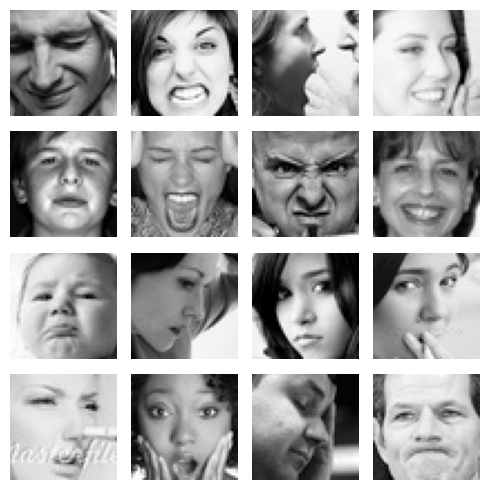

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# خدي Batch من الصور
images, _ = next(train_generator)

# عدد الصور اللي هنعرضها
num_images = 16
plt.figure(figsize=(5,5))  # زيادة حجم الشكل لعرض الصور بوضوح أكبر

for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i], cmap='gray')  # عرض الصورة مباشرة بدون تغيير الحجم
    plt.axis('off')  # إخفاء المحاور

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras import layers, models

# بناء نموذج CNN
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),  # طبقة التلافيف
    layers.MaxPooling2D((2, 2)),  # طبقة التجميع
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),  # تسطيح الخرج
    layers.Dense(128, activation='relu'),
    layers.Dense(7, activation='softmax')  # عدد الفئات = 7
])

# طباعة ملخص النموذج
cnn_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 23, 23, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 4, 4, 128)         0

In [ ]:
!pip install tensorflow==2.15.0
!pip install keras==2.15.0


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# نموذج ViT بسيط
def build_vit_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # تحويل الصورة إلى patches
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # تحويل الكود لتضمين طبقات ViT هنا أو استخدام طبقات أخرى
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, x)
    return model

# بناء النموذج
vit_model = build_vit_model(input_shape=(48, 48, 1), num_classes=7)

# ملخص النموذج
vit_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 1)]       0         
                                                                 
 rescaling (Rescaling)       (None, 48, 48, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 48, 48, 64)        640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 64)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 36864)             0         
                                                                 
 dense (Dense)               (None, 128)               4718720   
                                                             

In [ ]:
from tensorflow.keras import layers, models

# دمج المخرجات من النموذجين (CNN و ViT)
combined = layers.concatenate([cnn_model.output, vit_model.output])

# طبقة كثيفة لتصنيف الفئات
final_output = layers.Dense(7, activation='softmax')(combined)

# بناء النموذج النهائي
final_model = models.Model(inputs=[cnn_model.input, vit_model.input], outputs=final_output)

# ملخص النموذج النهائي
final_model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 conv2d_1_input (InputLayer  [(None, 48, 48, 1)]          0         []                            
 )                                                                                                
                                                                                                  
 conv2d_1 (Conv2D)           (None, 46, 46, 32)           320       ['conv2d_1_input[0][0]']      
                                                                                                  
 max_pooling2d_1 (MaxPoolin  (None, 23, 23, 32)           0         ['conv2d_1[0][0]']            
 g2D)                                                                                             
                                                                                            

1/1 [==============================] - 0s 60ms/step


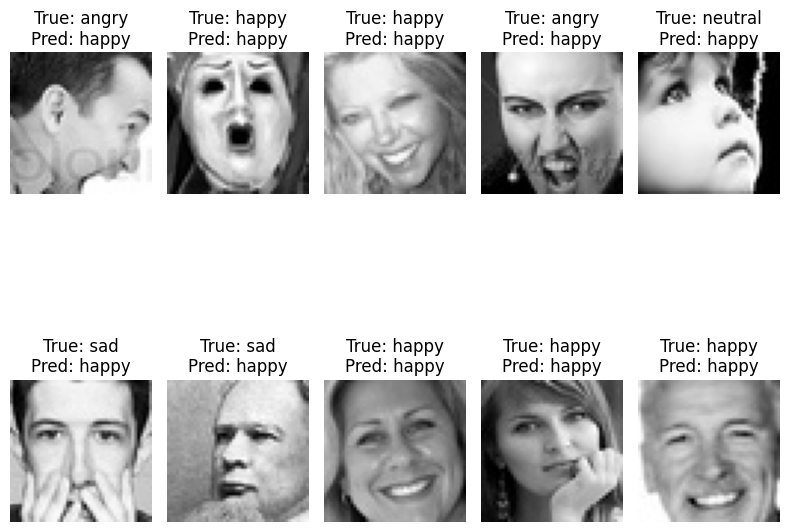

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# خدي Batch من بيانات الترين
train_images, train_labels = next(train_generator)

# مرري البيانات على النموذج عشان نجيب التوقعات
# Provide the same image data for both inputs of the final_model
predictions = final_model.predict([train_images, train_images])

# حولي النتائج من One-hot إلى أرقام
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(train_labels, axis=1)
class_labels = list(train_generator.class_indices.keys())

# عرض أول 10 صور مع التصنيفات
plt.figure(figsize=(8, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i].reshape(48, 48), cmap='gray')  # لو grayscale
    plt.axis('off')
    plt.title(f"True: {class_labels[true_classes[i]]}\nPred: {class_labels[predicted_classes[i]]}")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# حساب الدقة بناءً على التوقعات والتصنيفات الحقيقية
batch_accuracy = accuracy_score(true_classes, predicted_classes) * 100
print(f"Accuracy on this training batch: {batch_accuracy:.2f}%")


Accuracy on this training batch: 34.38%


In [ ]:
print(f"Total layers in the model: {len(final_model.layers)}")


Total layers in the model: 20


1/1 [==============================] - 0s 66ms/step


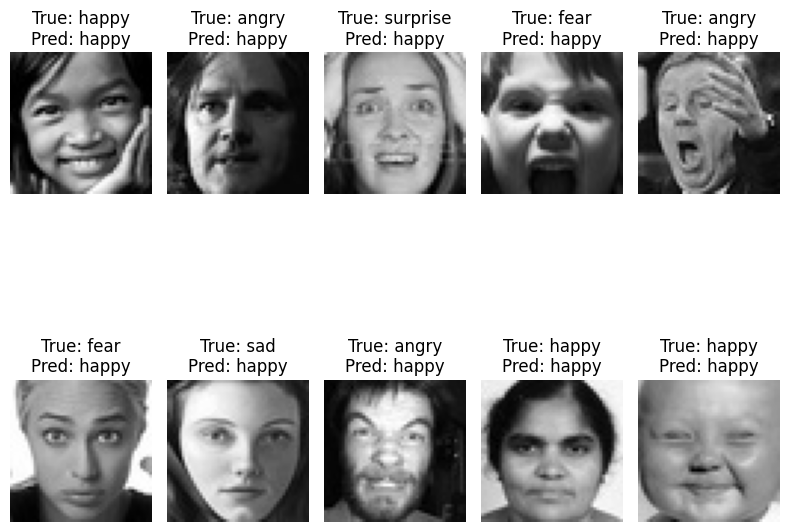

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# خدي دفعة (batch) من بيانات الـ test
test_images, test_labels = next(test_generator)  # لازم يكون test_generator معرف بنفس طريقة train_generator

# توقع النموذج
# Pass the test_images data as a list with two elements, corresponding to the two inputs the model expects
predictions = final_model.predict([test_images, test_images])

# تحويل التوقعات والمؤشرات إلى labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)
class_labels = list(test_generator.class_indices.keys())  # أسماء الفئات

# عرض أول 10 صور مع التصنيفات المتوقعة والحقيقية
plt.figure(figsize=(8, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].reshape(48, 48), cmap='gray')  # 48x48 صور رمادية
    plt.axis('off')
    plt.title(f"True: {class_labels[true_classes[i]]}\nPred: {class_labels[predicted_classes[i]]}")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# حساب الدقة بناءً على التوقعات والتصنيفات الحقيقية
test_batch_accuracy = accuracy_score(true_classes, predicted_classes) * 100
print(f"Accuracy on this test batch: {test_batch_accuracy:.2f}%")


Accuracy on this test batch: 34.38%


In [ ]:
print(f"Total layers in the model: {len(final_model.layers)}")


Total layers in the model: 20
